Attacker and Defender strategy simaltaneous optimization

0. Setup
- Operation area's characteristics are globally shared
i.e. map bound, defender's search pattern, static obstacle locations, etc

1. Attacker optimiztaion (Joseph)
- Attacker generates initial guess based on setup

2. Defender optimization (Jeff)
- Defender optimize based on attacker's opitmized path

In [1]:
# Import
import numpy as np
import random as rn
import casadi as ca
import os, json
from scipy.interpolate import splprep, splev
import importlib
import csv
from scipy.interpolate import interp1d
import time
import math

# Import Graphics
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.patches as patches
from IPython.display import HTML
from matplotlib.patches import Polygon as PolyPatch, Wedge, FancyArrow

# Import Customized python classes
from convex_map import generate_map
from map_visualization import _bounce_angle, animate_camera_rotation, visualize_map_at_time
from json_seriablizable import make_json_serializable
from Camera import Camera
import Dynamic
import STP_RRTStar
import convex_map

importlib.reload(Dynamic)
from Dynamic import DynamicMap
importlib.reload(STP_RRTStar)
from STP_RRTStar import STP_RRTStar as rrt

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
from datetime import datetime

# Generate current timestamp
now = datetime.now()

# Format: YYYYMMDD_HHMMSS (e.g., 20251230_131500)
timestamp = now.strftime("%Y%m%d_%H%M%S")

In [3]:
# General Setup of World Parameter288
map_size = (100, 100)
num_buildings = 8
num_direc_sensor = 5
num_omni_sensor = 5
num_sensors = num_direc_sensor + num_omni_sensor
fov_half_rad = np.deg2rad(30)
max_range = 25
panspeed_range = (np.deg2rad(-10), np.deg2rad(10))
cam_period = 200
cam_increment = 0.2
# rng_seed = 262
# rng_seed = 284 # This value osciliates
# rng_seed = 178
# rng_seed = 283 # Another oscilation
# rng_seed = rn.randint(1, 10000)
# rng_seed = 111 # Strong Oscillation // good
# rng_seed = 766 # oscilates
# rng_seed = 475 # Oscillates 
# rng_seed = 786
# rng_seed = 5942 # << another good good
rng_seed = 4134 # << This was GOOOD
print(rng_seed)

4134


(<Figure size 600x600 with 1 Axes>,
 <AxesSubplot:title={'center':'Operation Map @ t = 0.00'}>)

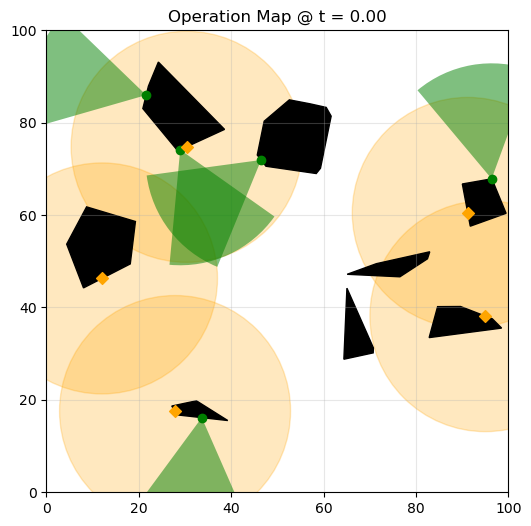

In [4]:
# Generate map
map_in, cam_dict = generate_map(
    map_size= map_size,
    num_buildings= num_buildings,
    num_directional_sensors= num_direc_sensor,
    num_omni_sensors= num_omni_sensor,
    fov_half_rad= fov_half_rad,
    max_range= max_range,
    fov_half_rad_omni= fov_half_rad,
    max_range_omni= max_range/2,
    panspeed_range= panspeed_range,
    cam_period= cam_period,
    cam_increment= cam_increment,
    rng_seed= rng_seed,
    balanced_sensors= False,
    param_lambda= [0.5, 0.5],
    param_beta= [0.4, 0.25]
)

# Parse map_in dictionarymap_size_val*0.1
map_size = map_in['st']['size']

visualize_map_at_time(map_in, cam_dict, t=0, sensor_alpha=0.5)

In [5]:
# Setup for Attacker Strategy: STP-RRT*
x0 = [0, 0, 0]
xf = [100, 100, 360]
vmax = 10

stp_rrt_setup = {}
stp_rrt_setup['x0'] = x0
stp_rrt_setup['xf'] = xf
stp_rrt_setup['vmax'] = vmax

# Output into JSON file
# Full path to the file
file_path1 = os.path.join("json/zero_sum_game", "operation_map.json")
file_path2 = os.path.join("json/zero_sum_game", "defender_info.json")
file_path3 = os.path.join("json/zero_sum_game", "stp_rrt_setup.json")

# Write JSON file into that folder
with open(file_path1, "w") as f:
    json.dump(make_json_serializable(map_in), f, indent=4)

with open(file_path2, "w") as f:
    json.dump(make_json_serializable(cam_dict), f, indent=4)

with open(file_path3, "w") as f:
    json.dump(stp_rrt_setup, f, indent=4)

In [6]:
# Generate Dynamic Map
dmap = DynamicMap(map_in, cam_dict)
map_in['dy'] = dmap

# Vehicle Spec
vehicle = {}
vehicle['v'] = vmax
vehicle['radius'] = 1

Initial Attacker Path generation with STP-RRT*
- if run_rrt = True: Run a new attacker path
- if run_rrt = False: load old attacker path

STP-RRT* initialized
k: 0, Convergence: 141.4213562373095
k: 1, Convergence: 9.889130122668094
k: 1, Convergence: 9.889130122668094
k: 1, Convergence: 9.889130122668094
k: 1, Convergence: 9.889130122668094
k: 1, Convergence: 9.889130122668094
k: 1, Convergence: 9.889130122668094
k: 1, Convergence: 9.889130122668094
k: 2, Convergence: 9.934663870690068
k: 3, Convergence: 19.086183754617792
k: 3, Convergence: 19.086183754617792
k: 3, Convergence: 131.48334960466434
k: 3, Convergence: 131.48334960466434
k: 3, Convergence: 131.5474361304896
k: 3, Convergence: 131.5474361304896
k: 3, Convergence: 131.5474361304896
k: 3, Convergence: 131.5474361304896
k: 4, Convergence: 9.796514015370787
k: 5, Convergence: 25.85797973797878
k: 5, Convergence: 25.85797973797878
k: 5, Convergence: 25.85797973797878
k: 5, Convergence: 25.85797973797878
k: 5, Convergence: 25.85797973797878
k: 5, Convergence: 25.85797973797878
k: 5, Convergence: 25.85797973797878
k: 5, Convergence: 25.85797973797878
k: 5, Converg

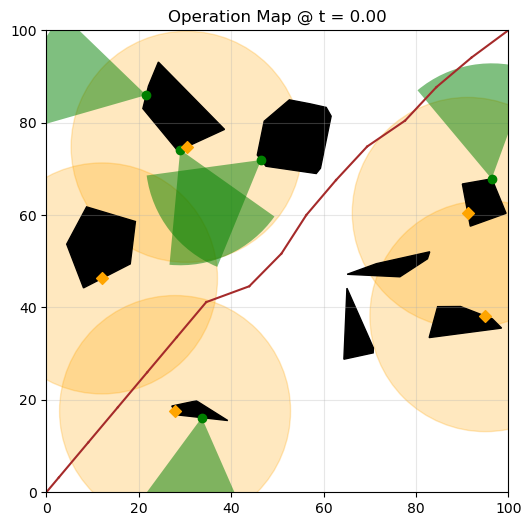

In [7]:
run_rrt = True
debug = True

# Initialize STP-RRT* Notebook
rrt_alg = rrt(vmax=vmax, xf=xf, map_size=map_size, vehicle=vehicle, cam_dict=cam_dict, dmap=dmap, max_time=1, map_in=map_in)

if run_rrt:
    
    # Run STP-RRT*
    # STP-RRT* Execution parameters
    x0 = x0          # start point
    nPartition = 5          # number of trees from the end point
    compTimeLimit = 300     # computation time limit

    min_dist = np.sqrt((x0[0]-xf[0])**2 + (x0[1]-xf[1])**2)
    min_time = min_dist/vmax

    tf0 = min_time                 # lower bound on end time randomization
    tfn = 25                # upper bound on end time randomization

    success_bool, comp_time, total_path_distance, total_path_time, success, path, V_start, V_goal, E_start, E_goal = rrt_alg.standard_Parallel_RRT(x0, nPartition, compTimeLimit, tf0, tfn, debug=debug)

    # Save Initial RRT result to a JSON File
    rrt_parameters={
        'success_bool': success_bool,
        'computation_time': comp_time,
        'path_distance': total_path_distance,
        'path_time': total_path_time,
        'path': path,
        'Vstart': V_start,
        'Vgoal': V_goal,
        'Estart': E_start,
        'Egoal': E_goal,
    }

    with open("json/zero_sum_game/rrt_parameters.json", "w") as f:
        json.dump(rrt_parameters, f, indent=4)
    print("STP-RRT* Results saved to rrt_parameters.json")
else:
    with open("json/zero_sum_game/rrt_parameters.json", 'r') as f:
    # with open("json/zero_sum_game/rrt_parameters_oscilation.json", 'r') as f:
        rrt_parameters = json.load(f)
        
    success_bool = rrt_parameters['success_bool']
    computation_time = rrt_parameters["computation_time"]
    total_path_distance = rrt_parameters["path_distance"]
    total_path_time = rrt_parameters["path_time"]
    path = rrt_parameters["path"]
    V_start = rrt_parameters["Vstart"]
    V_goal = rrt_parameters["Vgoal"]
    E_start = rrt_parameters["Estart"]
    E_goal = rrt_parameters["Egoal"]

# Visualize RRT result
visualize_map_at_time(map_in, cam_dict, t=0, sensor_alpha=0.5, algorithm_result=rrt_parameters)
print('Total Cost: '+str(rrt_alg.detection_cost_for_path(path)))

In [8]:
# Checking that the path obeys the maximum speed constraint
# Original Code written from Joseph
def verify_path_speed(path, vmax):
    """
    Verifies if any segment of the path exceeds vmax.
    Args:
        path: List of [x, y, t] points.
        vmax: Maximum allowed velocity.
    """
    # Convert to numpy array for easier calculation
    path_arr = np.array(path)
    
    # Calculate differences between consecutive points (dx, dy, dt)
    diffs = np.diff(path_arr, axis=0)
    dx = diffs[:, 0]
    dy = diffs[:, 1]
    dt = diffs[:, 2]

    # Calculate Euclidean distances
    distances = np.sqrt(dx**2 + dy**2)
    
    # Avoid division by zero issues
    # (If dt is 0, the speed is effectively infinite if dist > 0)
    dt_safe = np.maximum(dt, 1e-8) 
    
    # Calculate speeds: v = d / t
    speeds = distances / dt_safe

    # Identify violations
    # Using a small tolerance (1e-5) for floating point comparisons
    violation_indices = np.where(speeds > vmax + 1e-5)[0] 
    
    if len(violation_indices) > 0:
        print(f"⚠️ Speed Violation Detected: {len(violation_indices)} segments exceed vmax ({vmax})")
        print(f"   Maximum Speed Found: {np.max(speeds):.4f}")
        
        # Print the first few violations
        print("   First 3 violations:")
        for i in violation_indices[:3]:
            print(f"     Seg {i}->{i+1}: Speed={speeds[i]:.2f}, Dist={distances[i]:.2f}, Time={dt[i]:.4f}")
    else:
        print(f"✅ Path is valid. Max speed found: {np.max(speeds):.4f} (Limit: {vmax})")

# Run the check on your variables
verify_path_speed(path, vehicle['v'])

✅ Path is valid. Max speed found: 8.8511 (Limit: 10)


In [9]:
# Helper function to compute Half-Space parameters for a convex polygon
# Original code written by Joseph
def get_polygon_half_space_constraints(poly_vertices: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Computes A and b matrices for Ax <= b representation of a convex polygon.
    The constraint for avoidance will be A*p >= b + margin, or b - A*p <= -margin
    where p is the agent position.
    
    This function computes the *inward* pointing normal a_i and the offset b_i
    such that a_i^T * p <= b_i defines the INSIDE of the polygon.
    """
    
    A_list, b_list = [], []
    N_verts = len(poly_vertices)
    
    # Calculate centroid for inward/outward check
    # Note: polygon_centroid from convex_map uses NumPy but poly_vertices is a list of tuples initially
    # Ensure consistency; if poly_vertices is a NumPy array of (N, 2), this is fine.
    # We will use the centroid function from the imported convex_map
    centroid = convex_map.polygon_centroid([tuple(v) for v in poly_vertices])


        # CORRECTED CODE: Ensure poly_vertices is a list of tuples before passing to polygon_centroid
    # The map_in entry is a numpy array of arrays/lists (e.g., [[x1, y1], [x2, y2], ...])
    # We convert it back to the expected List[Tuple[float, float]] format for the utility function.
    # Let's ensure the inner elements are float/int pairs:
    if poly_vertices.ndim == 2:
        # This is a (N_verts, 2) array. Convert to a list of tuples.
        centroid = convex_map.polygon_centroid([tuple(v) for v in poly_vertices])
    else:
        # This must be the old [x, y, r] circular obstacle format that was accidentally left
        raise ValueError("Obstacle data is not a polygon vertex array. Check Cell 3 map setup.")
    
    for i in range(N_verts):
        v1 = poly_vertices[i]
        v2 = poly_vertices[(i + 1) % N_verts]
        
        # Edge vector (v2 - v1)
        ex, ey = v2[0] - v1[0], v2[1] - v1[1]
        
        # Candidate normal vector 1: n1 = (-ey, ex)
        # This is a counter-clockwise rotation from the edge vector (pointing left relative to edge direction v1->v2)
        n1 = np.array([-ey, ex])
        
        # Normalizing n1
        norm_n1 = np.linalg.norm(n1)
        if norm_n1 > 1e-6: # Avoid division by zero
            n1 = n1 / norm_n1

        # Check which normal points *inward* (toward the centroid)
        mid_point = (v1 + v2) / 2.0
        vec_to_centroid = np.array(centroid) - mid_point
        
        if np.dot(n1, vec_to_centroid) < 0:
            # n1 points OUT (Good!)
            a_i = n1
        else:
            # n1 points IN (Bad, flip it)
            a_i = -n1


            
        # Calculate the offset b_i using a point on the boundary (v1)
        b_i = np.dot(a_i, v1)
        
        A_list.append(a_i)
        b_list.append(b_i)

    # Return as NumPy arrays for CasADi/NumPy operations
    return np.array(A_list), np.array(b_list)

# Pre-calculate A and b for all buildings
obstacle_constraints = []
for i in range(map_in['st']['n']):
    # map_in['st'][str(i)] is an (N_verts, 2) numpy array of vertices
    poly_vertices = map_in['st'][str(i)]
    A, b = get_polygon_half_space_constraints(poly_vertices)
    obstacle_constraints.append({'A': A, 'b': b})

print(f"Pre-processed {len(obstacle_constraints)} convex polygon obstacles.")

Pre-processed 8 convex polygon obstacles.


CasADi Optimization
- Setup for optimization process using CasADi 


In [10]:
# Optimize defender with given attacker:
# For now, we only move camera positoin 
# Constraints: camera position only move along building edge

# Camera position parameterization
# Position of camera:
cam_x_direc = cam_dict['directional']['x']
cam_y_direc = cam_dict['directional']['y']
cam_x_omni = cam_dict['omnidirectional']['x']
cam_y_omni = cam_dict['omnidirectional']['y']

# Building param:
alpha_vec = []
building_edge_vec = []      # p0,j, start of building edge
building_vector_vec = []    # ve,j, direction of building edge

# Find edge of convex polygon with camera:
def closest_edge(building, cam_xy, tol=None):
    P = np.asarray(building, dtype=float)
    x = np.asarray(cam_xy, dtype=float)
    M = P.shape[0]
    assert M >= 3

    Pn = np.vstack([P, P[0]])
    Ls = np.linalg.norm(Pn[1:] - Pn[:-1], axis=1)
    Lmean = float(np.mean(Ls))
    if tol is None:
        tol = 1e-3 * Lmean if Lmean > 0 else 1e-6

    best = None
    for i in range(M):
        p0_i, p1_i = Pn[i], Pn[i+1]
        v_i = p1_i - p0_i
        L2 = float(v_i @ v_i)
        if L2 < 1e-16:
            continue
        t_raw = float((x - p0_i) @ v_i / L2)
        t_clamped = min(1.0, max(0.0, t_raw))
        proj_i = p0_i + t_clamped * v_i
        d2_i = float(np.sum((x - proj_i)**2))
        if (best is None) or (d2_i < best["d2"]):
            L = np.sqrt(L2)
            t_hat = v_i / L
            n_hat = np.array([-t_hat[1], t_hat[0]])
            best = dict(
                edge_idx=i, alpha=t_clamped, proj=proj_i, d2=d2_i,
                tangent=t_hat, normal=n_hat, p0=p0_i, p1=p1_i
            )

    dist = float(np.sqrt(best["d2"])) if best is not None else np.inf
    is_on = bool(dist <= tol)

    vertex_hit = None
    vdist = np.linalg.norm(P - x, axis=1)
    v_idx = int(np.argmin(vdist))
    if float(vdist[v_idx]) <= tol:
        vertex_hit = v_idx

    # *** CRITICAL: compute v_e from best['p1'] and best['p0'], not loop vars ***
    v_e = best["p1"] - best["p0"]

    best.update({
        "is_on_building": is_on,
        "distance": dist,
        "vertex_hit": vertex_hit,
        "tol_used": float(tol),
        "v_e": v_e
    })
    return best

# Directional Sensor
for n_building in range(map_in['st']['n']):
    for n_sensor in range(cam_dict['n_direc']):
        pos_sensor_j = closest_edge(map_in['st'][str(n_building)], [cam_x_direc[n_sensor],cam_y_direc[n_sensor]])
        
        if pos_sensor_j['is_on_building']:
            alpha_vec.append(pos_sensor_j['alpha'])
            building_edge_vec.append(pos_sensor_j['p0'])
            building_vector_vec.append(pos_sensor_j['v_e'])

# Omnidirectional Sensor            
for n_building in range(map_in['st']['n']):
    for n_sensor in range(cam_dict['n_omni']):
        pos_sensor_j = closest_edge(map_in['st'][str(n_building)], [cam_x_omni[n_sensor], cam_y_omni[n_sensor]])
        
        if pos_sensor_j['is_on_building']:
            alpha_vec.append(pos_sensor_j['alpha'])
            building_edge_vec.append(pos_sensor_j['p0'])
            building_vector_vec.append(pos_sensor_j['v_e'])
            
# print('alpha_j:'+str(alpha_vec))
# print('building_vec: '+str(building_vector_vec))
# print('building_edge: '+str(building_edge_vec))

In [11]:
# Cost function at given time ti
# Use Elfes's model
# Adopt method from Joseph's code:
# Distance decay variable
alpha_direc = 99/(cam_dict['directional']['spec']['fov'][1]**2)
alpha_omni = 99/(cam_dict['omnidirectional']['spec']['fov'][1]**2)

# Steepness of visibility
c_param = 10

def stage_detectability(x, y, t, S, camera_objects):
    """
    k(x, y, t; S) in [0, 1]
    x, y, t : casadi scalar of space-time vertex [x, y, t]
    """
    k_prod = 1.0
        
    for cam_i in range(cam_dict['n']):
        # Distances
        dx = x - S[0, cam_i]
        dy = y - S[1, cam_i]
        dist_sq = dx**2 + dy**2
        
        dist_min_sq = ca.fmax(dist_sq, 1e-4)
        dist_safe = ca.sqrt(dist_min_sq)
        
        # For directional sensors:
        if cam_i < cam_dict['n_direc']:
            cam = camera_objects[cam_i]
            phi = cam.get_ctr_theta_t(t)  # Use Camera.py method
            theta = cam.fov_ang
            cos_alpha = (dx*ca.cos(phi) + dy*ca.sin(phi))/dist_safe
            visibility = 1/(1+ca.exp(-c_param*(cos_alpha - ca.cos(theta/2))))
            observability = 1/(1+alpha_direc*dist_min_sq)
        else:
            visibility = 1
            observability = 1/(1+alpha_omni*dist_min_sq)
    
        k_j = visibility*observability
        k_prod *= (1 - k_j)
    
    # Probabilistic over sensors
    k_total = 1 - k_prod
    return k_total

# --- Generate Camera Objects ---
camera_objects = []
for i in range(cam_dict['n_direc']):
    cam_obj = Camera(i, cam_dict, cam_dict['directional']['x'][i], cam_dict['directional']['y'][i])
    camera_objects.append(cam_obj)

# Trajectory cost C(A, S)
M = cam_dict['n']
n_d = cam_dict['n_direc']

dt1_vec  = []
dt2_vec  = []
lam_vec  = []
beta_vec = []

for j in range(M):
    sensor_type = 'directional' if j < n_d else 'omnidirectional'

    dt1_vec.append(cam_dict[sensor_type]['spec']['fov'][1] / 100.0)
    dt2_vec.append(cam_dict[sensor_type]['spec']['fov'][1])
    lam_vec.append(cam_dict['detection'][sensor_type]['param_lambda'])
    beta_vec.append(cam_dict['detection'][sensor_type]['param_beta'])

dt1_vec  = np.array(dt1_vec, dtype=float)
dt2_vec  = np.array(dt2_vec, dtype=float)
lam_vec  = np.array(lam_vec, dtype=float)
beta_vec = np.array(beta_vec, dtype=float)

# def C_AS(A, S, dt1_vec, dt2_vec, lam_vec, beta_vec, eps=1e-9):
def C_AS(A, S, eps=1e-9):
    N = A.shape[1]
    C = 0
    for i in range(N):
        x_i = A[0, i]
        y_i = A[1, i]
        t_i = A[2, i]  # kept for signature compatibility (not used in pure range model)

        k_i = stage_detectability(x_i, y_i, t_i, S, camera_objects)
        C += -ca.log(1.0 - k_i + eps)
    return C

def build_C_function(N, M):
    A = ca.MX.sym('A', 3, N) # Attacker Trajectory
    S = ca.MX.sym('S', 2, M) # Defender Configuration
    C = C_AS(A, S)
    
    return ca.Function('DetectionCost', [A, S], [C], ['A', 'S'], ['cost'])

In [12]:
def optimize_defender(A_fixed, rho=0.0):
    opti_d = ca.Opti()

    # Defender Param
    total_number_of_sensors = cam_dict['n']
    total_directional_sensors = cam_dict['n_direc']
    total_omnidirectional_sensors = cam_dict['n_omni']

    alpha_j = opti_d.variable(total_number_of_sensors)

    # Add constraint for alpha_j
    opti_d.subject_to(alpha_j >= 0)
    opti_d.subject_to(alpha_j <= 1)

    # Setup sensor position S
    Sx = []
    Sy = []
    for j in range(total_number_of_sensors):
        p1 = building_edge_vec[j]
        s = p1 + alpha_j[j]*building_vector_vec[j]
        Sx.append(s[0])
        Sy.append(s[1])
        
    S = ca.vertcat(ca.hcat(Sx), ca.hcat(Sy)) #Shape 2, M

    # Attacker Param
    # path_arr = np.array(path)

    # rrt_x = path_arr[:, 0]
    # rrt_y = path_arr[:, 1]
    # rrt_t = path_arr[:, 2]

    # Number of evaluation points for defender cost
    # N_eval_defender = len(path_arr)
    N_eval_defender = A_fixed.shape[1]

    # Attacker trajectory parameter (fixed during defender solve)
    A_param = opti_d.parameter(3, N_eval_defender)
    # A_fixed = np.vstack([rrt_x, rrt_y, rrt_t]) # shape (3, N_eval_defender)
    opti_d.set_value(A_param, A_fixed)

    # Build Defender Objective
    # C = C_AS(A_param, S, dt1_vec, dt2_vec, lam_vec, beta_vec, eps=1e-9)
    C = C_AS(A_param, S)

    # Defender maximizes detection -> minimize -C (This is for single-iter)
    opti_d.minimize(-C)
    opti_d.set_initial(alpha_j, 0.5*np.ones(total_number_of_sensors))

    # Solver options
    p_opts = {
        "expand": False,
        "verbose": False,           # Ensures no extra CasADi debug info
        "print_time": False,
    }
    s_opts = {
        'max_iter': 3000,
        'tol': 1e-6,
        'acceptable_tol': 1e-4,
        'print_level': 0,
        "sb": "yes",                # Silences the Ipopt banner (the version info)
        "print_timing_statistics": "no", # Silences the final time summary
    }


    # Choose solver
    opti_d.solver('ipopt', p_opts, s_opts)


    # Solve
    try:
        sol_d = opti_d.solve()
        alpha_star = sol_d.value(alpha_j)
        S_star = sol_d.value(S)
        # S_star = np.column_stack([
        #     building_edge_vec[j] + alpha_star[j]*building_vector_vec[j] for j in range(M)
        # ])
        C_star = sol_d.value(C)
    except RuntimeError as e:
        print('Magos, this machine spirit is tainted:', e)
        alpha_star = opti_d.debug.value(alpha_j)
        S_star = opti_d.debug.value(S)
        C_star = opti_d.debug.value(C)
    return alpha_star, S_star, C_star, sol_d

In [13]:
def interpolate_rrt_path_preserve_speed(rrt_path, num_points):
        """
        Interpolates the original STP-RRT path using time-based interpolation,
        preserving the original speed profile.

        Parameters:
        - rrt_path: list of [x, y, t] points from STP-RRT
        - num_points: number of interpolated points to generate

        Returns:
        - x_interp: list of interpolated x positions
        - y_interp: list of interpolated y positions
        - t_interp: list of interpolated time values
        """
        rrt_array = np.array(rrt_path)
        x = rrt_array[:, 0]
        y = rrt_array[:, 1]
        t = rrt_array[:, 2]

        # Create interpolation functions for x(t) and y(t)
        fx = interp1d(t, x, kind='linear')
        fy = interp1d(t, y, kind='linear')

        # Generate evenly spaced time values
        t_interp = np.linspace(t[0], t[-1], num_points)

        # Interpolate positions
        x_interp = fx(t_interp)
        y_interp = fy(t_interp)

        return x_interp.tolist(), y_interp.tolist(), t_interp.tolist()

def optimize_attacker(S_fixed, S_star, N=1000):
    start_time = path[0][2]
    end_time = path[-1][2]

    opti_a = ca.Opti()

    # Set timestamps
    # N = 1000

    # Total travel time T as decision variable
    T = opti_a.variable()

    # Derived: per-step time
    dt = T/N

    opti_a.subject_to(T >= 1e-3)
    opti_a.subject_to(T <= end_time*1.5)

    # Decision_variables
    x_a = opti_a.variable(N+1)  # UAV x coords
    y_a = opti_a.variable(N+1)  # UAV y coords

    # Initial position constraints
    opti_a.subject_to(x_a[0] == x0[0])
    opti_a.subject_to(y_a[0] == x0[1])
    # Final position constraints
    opti_a.subject_to(x_a[-1] == xf[0])
    opti_a.subject_to(y_a[-1] == xf[1])
    # Map bounds
    opti_a.subject_to(opti_a.bounded(map_size[0], x_a, map_size[1]))
    opti_a.subject_to(opti_a.bounded(map_size[2], y_a, map_size[3]))

    # Max speed constraint
    for Ni in range(N):
        dx = x_a[Ni+1] - x_a[Ni]
        dy = y_a[Ni+1] - y_a[Ni]
        opti_a.subject_to(dx**2 + dy**2 <= (vmax*dt)**2)
    # dx = x_a[1:] - x_a[:-1]
    # dy = y_a[1:] - y_a[:-1]
    # opti_a.subject_to(dx**2 + dy**2 <= (vmax*dt)**2)
        
    # Anchor S_star in opti_a
    S_param = opti_a.parameter(2, cam_dict['n'])
    opti_a.set_value(S_param, S_star)

    # if we want for initial setup
    S_fixed = opti_a.parameter(2, cam_dict['n'])
    cam_direc_x = cam_dict['directional']['x']
    cam_direc_y = cam_dict['directional']['y']
    cam_omni_x = cam_dict['omnidirectional']['x']
    cam_omni_y = cam_dict['omnidirectional']['y']
    cam_x = np.hstack((cam_direc_x, cam_omni_x))
    cam_y = np.hstack((cam_direc_y, cam_omni_y))
    opti_a.set_value(S_fixed, np.vstack((cam_x, cam_y)))
        
    # Cost
    camera_objects = []
    for i in range(cam_dict['n_direc']):
        # Use S_star[0, i] and S_star[1, i] (the numeric results)
        cam_obj = Camera(i, cam_dict, float(S_star[0, i]), float(S_star[1, i]))
        camera_objects.append(cam_obj)

    log_sum = 0
    gamma = 500
    vehicle_radius = 1
    buffer_dist = 1
    safety_margin = vehicle_radius + buffer_dist
    for Ni in range(N):
        p_k = ca.vertcat(x_a[Ni], y_a[Ni])
        t_i = start_time + Ni*dt
        k_Ni = stage_detectability(x_a[Ni], y_a[Ni], t_i, S_param, camera_objects)
        current_log_term = ca.log(1 - k_Ni + 1e-9)
        log_sum += current_log_term
        
        # Static Obstacles
        for obs_data in obstacle_constraints:
            A_obs = obs_data['A']
            b_obs = obs_data['b']
            h_i_vector = ca.mtimes(A_obs, p_k) - b_obs
            
            # Number of edges in this polygon
            num_edges = A_obs.shape[0]
            
            # Log_sum-EXP constraint for obstacle avoidance
            max_h = h_i_vector[0]
            for idx in range(1, num_edges):
                max_h = ca.fmax(max_h, h_i_vector[idx])
            lse_term = max_h + (1.0/gamma) * ca.log(ca.sum(ca.exp(gamma * (h_i_vector - max_h))))
            lse_debiased = lse_term - (ca.log(num_edges) / gamma)
            
            opti_a.subject_to(lse_debiased >= safety_margin)
        
    # Time penalty to encourage shorter travel time
    time_penalty = 0.02*T

    # Total cost
    J_total_cost = log_sum - time_penalty

    opti_a.minimize(-J_total_cost)

    # Interpolating RRT initial guess
    x_interp, y_interp, t_interp = interpolate_rrt_path_preserve_speed(path, N+1)

    # Use time-interpolated RRT as the initial guess
    opti_a.set_initial(x_a, x_interp)
    opti_a.set_initial(y_a, y_interp)
    T_init = float(path[-1][2]-path[0][2])
    opti_a.set_initial(T, T_init)

    # Obtain full symbolic decision variable vector
    w_sym = ca.vertcat(x_a, y_a, T)

    # Calculate log_sum for a particular path
    log_sum_evaluator = ca.Function('physical_cost_evaluator', [w_sym, S_param], [log_sum])
    # Calculate time penalty for a particular path
    penalty_cost_evaluator = ca.Function('penalty_cost_evaluator', [w_sym, S_param], [time_penalty])

    # Calculate PoD for initial path
    w0 = ca.vertcat(x_interp, y_interp, T_init)

    # Evaluate the log_sum for the initial path
    initial_log_sum_dm = log_sum_evaluator(w0, S_star)
    initial_log_sum_value = initial_log_sum_dm.full().item()
    # Evaluate the penalty cost for the initial path
    initial_penalty_cost_dm = penalty_cost_evaluator(w0, S_star)
    initial_penalty_cost_value = initial_penalty_cost_dm.full().item()

    # Calculate initial PoD of path
    initial_P_non_detection = np.exp(initial_log_sum_value)
    initial_P_detection = 1-initial_P_non_detection
    initial_total_cost = initial_log_sum_value - initial_penalty_cost_value

    # Solver options
    p_opts = {
        "expand": True,
        "verbose": False,           # Ensures no extra CasADi debug info
        "print_time": False,
    }
    s_opts = {
        'max_iter': 3000,
        'tol': 1e-6,
        'acceptable_tol': 1e-4,
        'print_level': 0,
        "sb": "yes",                # Silences the Ipopt banner (the version info)
        "print_timing_statistics": "no", # Silences the final time summary
    }

    # Solver
    opti_a.solver('ipopt', p_opts, s_opts)

    # Solve
    try:
        sol_a = opti_a.solve()
        x_a_opt = sol_a.value(x_a)
        y_a_opt = sol_a.value(y_a)
        T_opt = float(sol_a.value(T))
        log_sum_opt = sol_a.value(log_sum)
    except RuntimeError as e:
        print('Magos, this machine spirit is tainted:', e)
        x_a_opt = opti_a.debug.value(x_a)
        y_a_opt = opti_a.debug.value(y_a)
        T_opt = opti_a.debug.value(T)
        log_sum_opt = opti_a.debug.value(log_sum)

    # Build a numeric time vector for export / animation
    t_opt_num = np.linspace(start_time, start_time + T_opt, N+1)
    A_star = np.vstack((x_a_opt.T, y_a_opt.T, t_opt_num.T))
    return A_star, sol_a


In [14]:
############################################
# --- Attacker-Defender Iteratoin Setup ---
############################################
# Setup for iteration
# Initial attacker strategy A0
path_arr = np.array(path)
A_initial = path_arr.T
A_prev = A_initial.copy()

# Param for cycling
cycle_window = 4          # small, 3–6 is typical
cycle_tol = 1e-3          # how close two strategies must be to count as a repeat
eta_min = 0.05
eta_decay = 0.5

# Initial defender strategy alpha0
M = cam_dict['n']
eta = 0.3 # Damping factor (0 < eta <= 1)
rho = 1.0
alpha_init_vec = 0.5*np.ones(M)
# Corresponding initial sensor positions
S_init = np.column_stack([
    building_edge_vec[j]+alpha_init_vec[j]*building_vector_vec[j] for j in range(M)
])

# Alternative loop parameter
max_iters = 50
tol_alpha = 1e-3
tol_A = 1e-3
tol_cost = 1e-4
N_attk = 250 # Number of timestamp

# Sanity check:
print("Initial A shape:", A_initial.shape)   # (3, K)
print("Initial alpha:", alpha_init_vec)
print("Initial S shape:", S_init.shape)    # (2, M)

Initial A shape: (3, 16)
Initial alpha: [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
Initial S shape: (2, 10)


In [15]:
# Create symbolic representatives for the strategies
A_sym = ca.MX.sym('A_sym', A_initial.shape[0], N_attk+1)
S_sym = ca.MX.sym('S_sym', S_init.shape[0], S_init.shape[1])

# Create the symbolic cost expression using your existing C_AS function
# Ensure C_AS can handle symbolic MX inputs
J_sym = C_AS(A_sym, S_sym)
# 1. Flatten the matrices into vectors
A_flat = ca.reshape(A_sym, -1, 1)
S_flat = ca.reshape(S_sym, -1, 1)
z = ca.vertcat(A_flat, S_flat) # The combined game state

# 2. Define the game vector field (The 'Force' field)
# Attacker maximizes J (minimizes -J), Defender minimizes J
v = ca.vertcat(ca.reshape(ca.gradient(-J_sym, A_sym), -1, 1),
               ca.reshape(ca.gradient(J_sym, S_sym), -1, 1))

# 3. Compute the Game Jacobian
# This is a matrix of size (N_vars x N_vars)
J_game_expr = ca.jacobian(v, z)

# 4. Create the Evaluator
get_game_jacobian = ca.Function('gj', [A_sym, S_sym], [J_game_expr])

In [16]:
# Debugging check
debug = True

# Storage history
defender_cost_history = []
attacker_cost_history = []
payoff_history = []
alpha_history = []
A_history = []
S_history = []
stopping_criteria_log = {}
stopping_criteria_log['sensor_shift'] = []
stopping_criteria_log['cost_shift'] = []
stopping_criteria_log['eig_val'] = {}
stopping_criteria_log['eig_val']['eig_A'] = []
stopping_criteria_log['eig_val']['eig_S'] = []

sol_a_init = None
sol_d_init = None

J_A_at_ABR_vs_D_Init = 0
J_D_at_ABR_vs_D_Init = 0
J_A_at_DBR_vs_A_Init = 0
J_D_at_ABR_vs_A_Init = 0

# Initialization
alpha_prev_vec = alpha_init_vec.copy()
A_prev = A_initial.copy()
S_prev = S_init.copy()

# Cost at start of the iteration
J_tot_init = C_AS(A_initial, S_init, eps=1e-9)
prev_total_cost = 0
payoff_history.append(J_tot_init)

# Iteration
for attacker_defender_iter in range(max_iters):
    if debug:
        print('######################################################################')
        print('Iteration: '+str(attacker_defender_iter))
    # Storing old data
    alpha_old = alpha_prev_vec.copy()
    A_old = A_prev.copy()
    
    ######################################################################
    # --- Optimize defender strategy given fixed attacker strategy ---
    ######################################################################
    try:
        alpha_star, S_star, C_defender, sol_d = optimize_defender(A_fixed=A_prev, rho=rho)
    except RuntimeError as e:
        print('Magos, this machine spirit is tainted:', e)
        continue
    
    # Defender cost
    # J_def_k = C_AS(A_prev, S_star)
    # log_sum_def = float(sol_d.value(J_def_k))
    # val_def = 1.0 - np.exp(-log_sum_def)
    # defender_cost_history.append(val_def)
    J_def_k = C_AS(A_prev, S_star)
    if sol_d is not None:
        log_sum_def = float(sol_d.value(J_def_k))
    else:
        log_sum_def = float(J_def_k)
    val_def = 1.0 - np.exp(-log_sum_def)
    defender_cost_history.append(val_def)

    #####################################################################
    # --- Optimize attacker strategy given fixed defender strategy ---
    #####################################################################
    try:
        A_star, sol_a = optimize_attacker(S_fixed=S_prev, S_star=S_star, N=N_attk)
        # A_star = optimize_attacker(S_fixed=S_prev, S_star=S_star, N=N_attk)
    except RuntimeError as e:
        print('Magos, this machine spirit is tainted:', e)
        continue
    
    #  Attacker cost
    # J_att_k = C_AS(A_star, S_prev, eps=1e-9)
    # log_sum_att = float(sol_a.value(J_att_k))
    # val_att = 1.0 - np.exp(-log_sum_att)
    # attacker_cost_history.append(val_att)

    J_att_k = C_AS(A_star, S_prev, eps=1e-9)
    if sol_a is not None:
        log_sum_att = float(sol_a.value(J_att_k))
    else:
        log_sum_att = float(J_att_k)
    val_att = 1.0 - np.exp(-log_sum_att)
    attacker_cost_history.append(val_att)
    
    alpha_history.append(alpha_star.copy())
    A_history.append(A_star.copy())
    S_history.append(S_star.copy())

    if attacker_defender_iter == 1:
        sol_a_init = sol_a
        sol_d_init = sol_d

    #####
    J_A_at_ABR_vs_D_Init = sol_a.value(C_AS(A_prev, S_init, eps=1e-9))
    J_D_at_ABR_vs_D_Init = sol_d.value(C_AS(A_prev, S_init, eps=1e-9))
    J_A_at_DBR_vs_A_Init = sol_a.value(C_AS(A_initial, S_prev, eps=1e-9))
    J_D_at_ABR_vs_A_Init = sol_d.value(C_AS(A_initial, S_prev, eps=1e-9))

    #####################################################################
    #                  --- Update for next iteration ---
    #####################################################################
    # Total cost at given end of iteration
    J_total_k = C_AS(A_star, S_star)
    log_sum_total = float(sol_d.value(J_total_k))
    val_total = 1.0 - np.exp(-log_sum_total)
    payoff_history.append(val_total)
    
    ######################################################################
    #                    --- Stopping criteria ---
    ######################################################################
    # Convergence diagnostics
    # 1. Cost comparison
    current_total_cost = val_total
    cost_diff = abs(current_total_cost - prev_total_cost)
    # 2. Stability of strategy (avoid shifting or cycling of position while maintaining cost)
    sensor_shift = np.linalg.norm(S_star - S_prev)
    # 3. Stationary / KKT Error
    # Evaluate the Jacobian at the solution
    numeric_J = get_game_jacobian(A_star, S_star)
    numeric_J = np.array(numeric_J) # Convert to numpy for analysis

    # Calculate Eigenvalues
    # 1. Is the Attacker at a local minimum?
    size_A = 3 * (N_attk + 1)
    eig_A = np.linalg.eigvals(numeric_J[:size_A, :size_A])
    # 2. Is the Defender at a local minimum?
    eig_S = np.linalg.eigvals(numeric_J[size_A:, size_A:])
    min_eig_A = np.min(np.real(eig_A))
    min_eig_S = np.min(np.real(eig_S))
    
    # Log terminal conditions
    stopping_criteria_log['sensor_shift'].append(sensor_shift)
    stopping_criteria_log['cost_shift'].append(cost_diff)
    stopping_criteria_log['eig_val']['eig_A'].append(min_eig_A)
    stopping_criteria_log['eig_val']['eig_S'].append(min_eig_S)
    
    # --- 1. CONVERGENCE CHECK (Movement) ---
    # If sensors and costs stop changing, the players have "settled"
    is_stable = (sensor_shift < 1e-5) and (cost_diff < 1e-5)
    
    if is_stable:
        if min_eig_A > 1e-5 and min_eig_S >-1e-5:
            # Best local optimum
            equilibrium_type = 'Uncontrained Local Nash'
            print('Praise the Omnissiah. Convergence has achieved!')
            break
        else:
            # Best local optimum within feasible set. Actual NE is unreachable as its outside of feasible set
            equilibrium_type = 'Constrained Local Nash'
            print('Praise the Omnissiah. Convergence has achieved!')
            break
    elif attacker_defender_iter >= 100:
        print('Magos, we have reached for maximum iteration.')
        break
    else:
        print('Magos, the machine spirit has failed')
        print('Sensor shift: '+str(sensor_shift))
        print('Cost difference: '+str(cost_diff))
        prev_total_cost = current_total_cost
        
    # if attacker_defender_iter < 13:
    #     print('Magos, the machine spirit has failed')
    #     print('Sensor shift: '+str(sensor_shift))
    #     print('Cost difference: '+str(cost_diff))
    #     prev_total_cost = current_total_cost
    # else:
    #     break
    
    # if sensor_shift <1e-3 and cost_diff < tol_cost and min_eig_A > -1e-5 and min_eig_S > -1e-5:
    #     print('Praise the Omnissiah. Convergence has achieved!')
    #     break
    # else:not
    #     print('Magos, the machine spirit has failed')
    #     print(f'Sensor shift: {sensor_shift: .7f}')
    #     print(f'Cost difference: {cost_diff: .7f}')
    #     print(f"Attacker Min Eigenvalue: {min_eig_A:.7e}")
    #     print(f"Defender Min Eigenvalue: {min_eig_S:.7e}")
    #     prev_total_cost = current_total_cost
    
    # Update A_prev, S_prev
    # A_prev = A_star.copy()
    # S_prev = S_star.copy()
    eta = 0.3
    if attacker_defender_iter == 0:
        x_interp, y_interp, t_interp = interpolate_rrt_path_preserve_speed(path, N_attk+1)
        A_prev = np.vstack((x_interp, y_interp, t_interp))
    A_prev = (1 - eta) * A_prev + eta * A_star
    S_prev = (1 - eta) * S_prev + eta * S_star
    
    # for debugging
    if debug:
        print(f'Defender Cost: {val_def: .4f}')
        print(f'Attacker Cost: {val_att: .4f}')
        print(f'Overall Cost: {val_total: .4f}')

######################################################################
Iteration: 0
Magos, the machine spirit has failed
Sensor shift: 13.402772118032278
Cost difference: 0.8018002483197166
Defender Cost:  0.1837
Attacker Cost:  0.7855
Overall Cost:  0.8018
######################################################################
Iteration: 1
Magos, the machine spirit has failed
Sensor shift: 10.033591818361021
Cost difference: 0.0016082777368023882
Defender Cost:  0.9361
Attacker Cost:  0.7902
Overall Cost:  0.8002
######################################################################
Iteration: 2
Magos, the machine spirit has failed
Sensor shift: 7.024794048177362
Cost difference: 4.1723152099937266e-07
Defender Cost:  0.8959
Attacker Cost:  0.7928
Overall Cost:  0.8002
######################################################################
Iteration: 3
Magos, the machine spirit has failed
Sensor shift: 5.069568101273029
Cost difference: 0.0027631331283793914
Defender Cost:  0.8657
Attac

In [17]:
##############################################################################
# --- Cell 19: eval_C_numeric + Simultaneous Nash Solve ---
##############################################################################

from scipy.interpolate import interp1d as scipy_interp1d

def eval_C_numeric(A_np, S_np):
    """Evaluate detection cost C(A,S) numerically."""
    N = A_np.shape[1]
    M = S_np.shape[1]
    A_sym_ = ca.MX.sym('A_', 3, N)
    S_sym_ = ca.MX.sym('S_', 2, M)
    C_expr = C_AS(A_sym_, S_sym_)
    C_fn   = ca.Function('C_fn', [A_sym_, S_sym_], [C_expr])
    return float(C_fn(A_np, S_np))


def optimize_simultaneous(A_init_np, S_init_np, alpha_init_np, N=None):
    """
    Simultaneous Nash: solve stationarity conditions for both players at once.
    Attacker minimizes C, defender stationarity enforced as constraint.
    Defender boundary: alpha_j in [0,1] on building edge.
    """
    if N is None:
        N = N_attk

    start_time  = path[0][2]
    end_time    = path[-1][2]
    M_sensors   = cam_dict['n']

    opti = ca.Opti()

    # Decision variables
    x_a     = opti.variable(N + 1)
    y_a     = opti.variable(N + 1)
    T       = opti.variable()
    alpha_j = opti.variable(M_sensors)

    dt = T / N

    # Sensor positions from alpha_j
    Sx, Sy = [], []
    for j in range(M_sensors):
        p0_j = building_edge_vec[j]
        s_j  = p0_j + alpha_j[j] * building_vector_vec[j]
        Sx.append(s_j[0]); Sy.append(s_j[1])
    S = ca.vertcat(ca.hcat(Sx), ca.hcat(Sy))

    # Camera objects — freeze heading at ABR positions
    cam_objs_sim = []
    for i in range(cam_dict['n_direc']):
        cam_objs_sim.append(Camera(i, cam_dict,
                                   float(S_init_np[0, i]),
                                   float(S_init_np[1, i])))

    # Build C(A, S) symbolically
    t_nodes = [start_time + i * dt for i in range(N + 1)]
    log_sum = 0
    for i in range(N + 1):
        xi = x_a[i]; yi = y_a[i]; ti = t_nodes[i]
        k_prod = 1.0
        for cam_i in range(M_sensors):
            dx_i      = xi - S[0, cam_i]
            dy_i      = yi - S[1, cam_i]
            dist_sq   = dx_i**2 + dy_i**2
            dist_min  = ca.fmax(dist_sq, 1e-4)
            dist_safe = ca.sqrt(dist_min)
            if cam_i < cam_dict['n_direc']:
                cam_obj = cam_objs_sim[cam_i]
                phi     = cam_obj.get_ctr_theta_t(ti)
                theta   = cam_obj.fov_ang
                cos_a   = (dx_i*ca.cos(phi) + dy_i*ca.sin(phi)) / dist_safe
                vis     = 1 / (1 + ca.exp(-c_param*(cos_a - ca.cos(theta/2))))
                obs     = 1 / (1 + alpha_direc*dist_min)
            else:
                vis = 1.0
                obs = 1 / (1 + alpha_omni*dist_min)
            k_j     = vis * obs
            k_prod *= (1 - k_j)
        k_total  = 1 - k_prod
        log_sum += -ca.log(1.0 - k_total + 1e-9)

    C_joint = log_sum - 0.02*T

    # Objective: attacker minimizes C
    opti.minimize(C_joint)

    # Attacker constraints
    opti.subject_to(T >= 1e-3)
    opti.subject_to(T <= end_time * 1.5)
    opti.subject_to(x_a[0] == x0[0]); opti.subject_to(y_a[0] == x0[1])
    opti.subject_to(x_a[-1] == xf[0]); opti.subject_to(y_a[-1] == xf[1])
    opti.subject_to(opti.bounded(map_size[0], x_a, map_size[1]))
    opti.subject_to(opti.bounded(map_size[2], y_a, map_size[3]))
    for k in range(N):
        dx_s = x_a[k+1] - x_a[k]; dy_s = y_a[k+1] - y_a[k]
        opti.subject_to(dx_s**2 + dy_s**2 <= (vmax*dt)**2)

    # Obstacle avoidance
    gamma_obs = 500; safety_margin = vehicle['radius'] + 1
    for k in range(N + 1):
        p_k = ca.vertcat(x_a[k], y_a[k])
        for obs_data in obstacle_constraints:
            A_obs = obs_data['A']; b_obs = obs_data['b']
            h_vec = ca.mtimes(A_obs, p_k) - b_obs
            n_e   = A_obs.shape[0]
            max_h = h_vec[0]
            for idx in range(1, n_e):
                max_h = ca.fmax(max_h, h_vec[idx])
            lse     = max_h + (1.0/gamma_obs)*ca.log(ca.sum(ca.exp(gamma_obs*(h_vec-max_h))))
            lse_deb = lse - (ca.log(n_e)/gamma_obs)
            opti.subject_to(lse_deb >= safety_margin)

    # Defender stationarity: grad_{alpha_j} C = 0 for each sensor
    # This is the KKT condition for defender's maximization over alpha_j in [0,1]
    w_D    = alpha_j
    grad_D = ca.gradient(C_joint, w_D)
    for j in range(M_sensors):
        opti.subject_to(grad_D[j] == 0)

    # Defender boundary
    opti.subject_to(alpha_j >= 0)
    opti.subject_to(alpha_j <= 1)

    # Warm start
    fi = scipy_interp1d(np.array(path)[:,2], np.array(path)[:,0])
    fx = scipy_interp1d(np.array(path)[:,2], np.array(path)[:,1])
    t_new = np.linspace(path[0][2], path[-1][2], N+1)
    opti.set_initial(x_a,     A_init_np[0,:])
    opti.set_initial(y_a,     A_init_np[1,:])
    opti.set_initial(T,       float(A_init_np[2,-1] - A_init_np[2,0]))
    opti.set_initial(alpha_j, alpha_init_np)

    p_opts = {"expand": True, "verbose": False, "print_time": False}
    s_opts = {'max_iter': 3000, 'tol': 1e-5, 'acceptable_tol': 1e-4,
              'print_level': 0, 'sb': 'yes', 'print_timing_statistics': 'no'}
    opti.solver('ipopt', p_opts, s_opts)

    print('Praise the Omnissiah. Engaging simultaneous Nash solve...')
    try:
        sol      = opti.solve()
        x_opt    = sol.value(x_a)
        y_opt    = sol.value(y_a)
        T_opt    = float(sol.value(T))
        alpha_sim= sol.value(alpha_j)
        S_sim_val= sol.value(S)
        gD_res   = np.array(sol.value(grad_D)).flatten()
        print(f'  Solved. Max defender stationarity residual: {np.max(np.abs(gD_res)):.4e}')
    except RuntimeError as e:
        print(f'  Machine spirit faltered: {e}')
        x_opt    = opti.debug.value(x_a)
        y_opt    = opti.debug.value(y_a)
        T_opt    = float(opti.debug.value(T))
        alpha_sim= opti.debug.value(alpha_j)
        S_sim_val= opti.debug.value(S)
        gD_res   = np.array(opti.debug.value(grad_D)).flatten()
        print(f'  Debug. Max stationarity residual: {np.max(np.abs(gD_res)):.4e}')

    t_opt  = np.linspace(start_time, start_time + T_opt, N+1)
    A_sim  = np.vstack((x_opt, y_opt, t_opt))
    S_sim  = np.array(S_sim_val)

    C_sim = eval_C_numeric(A_sim, S_sim)
    print(f'  C(A_sim, S_sim) = {C_sim:.6f}  P_D = {1 - np.exp(-C_sim):.6f}')
    return A_sim, S_sim, alpha_sim, C_sim


##############################################################################
# --- Run ABR (Stackelberg) ---
##############################################################################
print('Running ABR (Stackelberg)...')
# ABR loop is already in Cell 18 — A_star, S_star, alpha_star should be set.
# If not, run Cell 18 first.
C_abr = eval_C_numeric(A_star, S_star)
print(f'ABR done. C(A_star, S_star) = {C_abr:.6f}  P_D = {1-np.exp(-C_abr):.6f}')

##############################################################################
# --- Run Simultaneous Nash ---
##############################################################################
print()
print('Running Simultaneous Nash...')
A_sim, S_sim, alpha_sim, C_sim_val = optimize_simultaneous(
    A_init_np     = A_star,
    S_init_np     = S_star,
    alpha_init_np = alpha_star,
    N             = N_attk
)


Running ABR (Stackelberg)...
ABR done. C(A_star, S_star) = 1.637592  P_D = 0.805552

Running Simultaneous Nash...
Praise the Omnissiah. Engaging simultaneous Nash solve...
  Machine spirit faltered: Error in Opti::solve [OptiNode] at .../casadi/core/optistack.cpp:217:
.../casadi/core/optistack_internal.cpp:1338: Assertion "return_success(accept_limit)" failed:
Solver failed. You may use opti.debug.value to investigate the latest values of variables. return_status is 'Infeasible_Problem_Detected'
  Debug. Max stationarity residual: 2.7126e-02
  C(A_sim, S_sim) = 4.645858  P_D = 0.990399


In [18]:
##############################################################################
# --- Cell 20: Stackelberg vs Nash Deviation Analysis ---
#
# Key question: given each solution, can either player gain by deviating?
#
# Stackelberg is the correct model for CUAS because:
#   - Defender commits sensor placement BEFORE attacker launches
#   - Attacker OBSERVES sensor placement and best-responds
#   => This is the Stackelberg leader-follower structure
#
# If Nash solution is unstable (attacker can deviate and gain), it shows
# Nash is not the right model when attacker can observe defender strategy.
##############################################################################

print("=" * 65)
print("STACKELBERG vs SIMULTANEOUS NASH: DEVIATION ANALYSIS")
print("=" * 65)

# ---- Baseline payoffs ----
C_stack = eval_C_numeric(A_star, S_star)
C_nash  = eval_C_numeric(A_sim,  S_sim)
print(f'\nBaseline payoffs:')
print(f'  Stackelberg C(A*, S*)  = {C_stack:.6f}  P_D = {1-np.exp(-C_stack):.4f}')
print(f'  Nash        C(A°, S°)  = {C_nash:.6f}  P_D = {1-np.exp(-C_nash):.4f}')

# ---- Attacker deviation: best-respond to each defender ----
print(f'\nAttacker deviation test (attacker observes S and best-responds):')

A_br_stack, _ = optimize_attacker(S_star, S_star, N=N_attk)
C_br_att_stack = eval_C_numeric(A_br_stack, S_star)
att_gain_stack = C_stack - C_br_att_stack
print(f'  vs Stackelberg S*: C(A_br, S*) = {C_br_att_stack:.6f}  '
      f'gain = {att_gain_stack:.4e}  '
      f'{"✅ stable" if att_gain_stack < 1e-3 else "❌ attacker can improve"}')

A_br_nash, _ = optimize_attacker(S_sim, S_sim, N=N_attk)
C_br_att_nash = eval_C_numeric(A_br_nash, S_sim)
att_gain_nash = C_nash - C_br_att_nash
print(f'  vs Nash       S°: C(A_br, S°) = {C_br_att_nash:.6f}  '
      f'gain = {att_gain_nash:.4e}  '
      f'{"✅ stable" if att_gain_nash < 1e-3 else "❌ attacker can improve"}')

# ---- Defender deviation: best-respond to each attacker ----
print(f'\nDefender deviation test (defender best-responds to A):')

alpha_br_stack, S_br_stack, _, _ = optimize_defender(A_star)
C_br_def_stack = eval_C_numeric(A_star, S_br_stack)
def_gain_stack = C_br_def_stack - C_stack
print(f'  vs Stackelberg A*: C(A*, S_br) = {C_br_def_stack:.6f}  '
      f'gain = {def_gain_stack:.4e}  '
      f'{"✅ stable" if def_gain_stack < 1e-3 else "❌ defender can improve"}')

alpha_br_nash, S_br_nash, _, _ = optimize_defender(A_sim)
C_br_def_nash = eval_C_numeric(A_sim, S_br_nash)
def_gain_nash = C_br_def_nash - C_nash
print(f'  vs Nash       A°: C(A°, S_br) = {C_br_def_nash:.6f}  '
      f'gain = {def_gain_nash:.4e}  '
      f'{"✅ stable" if def_gain_nash < 1e-3 else "❌ defender can improve"}')

# ---- Summary ----
print(f'\n{"=" * 65}')
print(f'{"SUMMARY":^65}')
print(f'{"=" * 65}')
print(f'{"Solution":<22} {"C":>8} {"P_D":>6} {"Att gain":>12} {"Def gain":>12} {"Stable?":>10}')
print(f'{"-" * 65}')
s_stable = att_gain_stack < 1e-3 and def_gain_stack < 1e-3
n_stable = att_gain_nash  < 1e-3 and def_gain_nash  < 1e-3
print(f'{"Stackelberg (ABR)":<22} {C_stack:>8.4f} {1-np.exp(-C_stack):>6.4f} '
      f'{att_gain_stack:>12.4e} {def_gain_stack:>12.4e} '
      f'{"✅ Yes" if s_stable else "⚠️  Partial":>10}')
print(f'{"Nash (Simultaneous)":<22} {C_nash:>8.4f} {1-np.exp(-C_nash):>6.4f} '
      f'{att_gain_nash:>12.4e} {def_gain_nash:>12.4e} '
      f'{"✅ Yes" if n_stable else "❌ No":>10}')
print(f'{"=" * 65}')


STACKELBERG vs SIMULTANEOUS NASH: DEVIATION ANALYSIS

Baseline payoffs:
  Stackelberg C(A*, S*)  = 1.637592  P_D = 0.8056
  Nash        C(A°, S°)  = 4.645858  P_D = 0.9904

Attacker deviation test (attacker observes S and best-responds):
  vs Stackelberg S*: C(A_br, S*) = 1.637592  gain = 0.0000e+00  ✅ stable
  vs Nash       S°: C(A_br, S°) = 1.494963  gain = 3.1509e+00  ❌ attacker can improve

Defender deviation test (defender best-responds to A):
  vs Stackelberg A*: C(A*, S_br) = 1.637593  gain = 1.2454e-06  ✅ stable
  vs Nash       A°: C(A°, S_br) = 4.747494  gain = 1.0164e-01  ❌ defender can improve

                             SUMMARY                             
Solution                      C    P_D     Att gain     Def gain    Stable?
-----------------------------------------------------------------
Stackelberg (ABR)        1.6376 0.8056   0.0000e+00   1.2454e-06      ✅ Yes
Nash (Simultaneous)      4.6459 0.9904   3.1509e+00   1.0164e-01       ❌ No


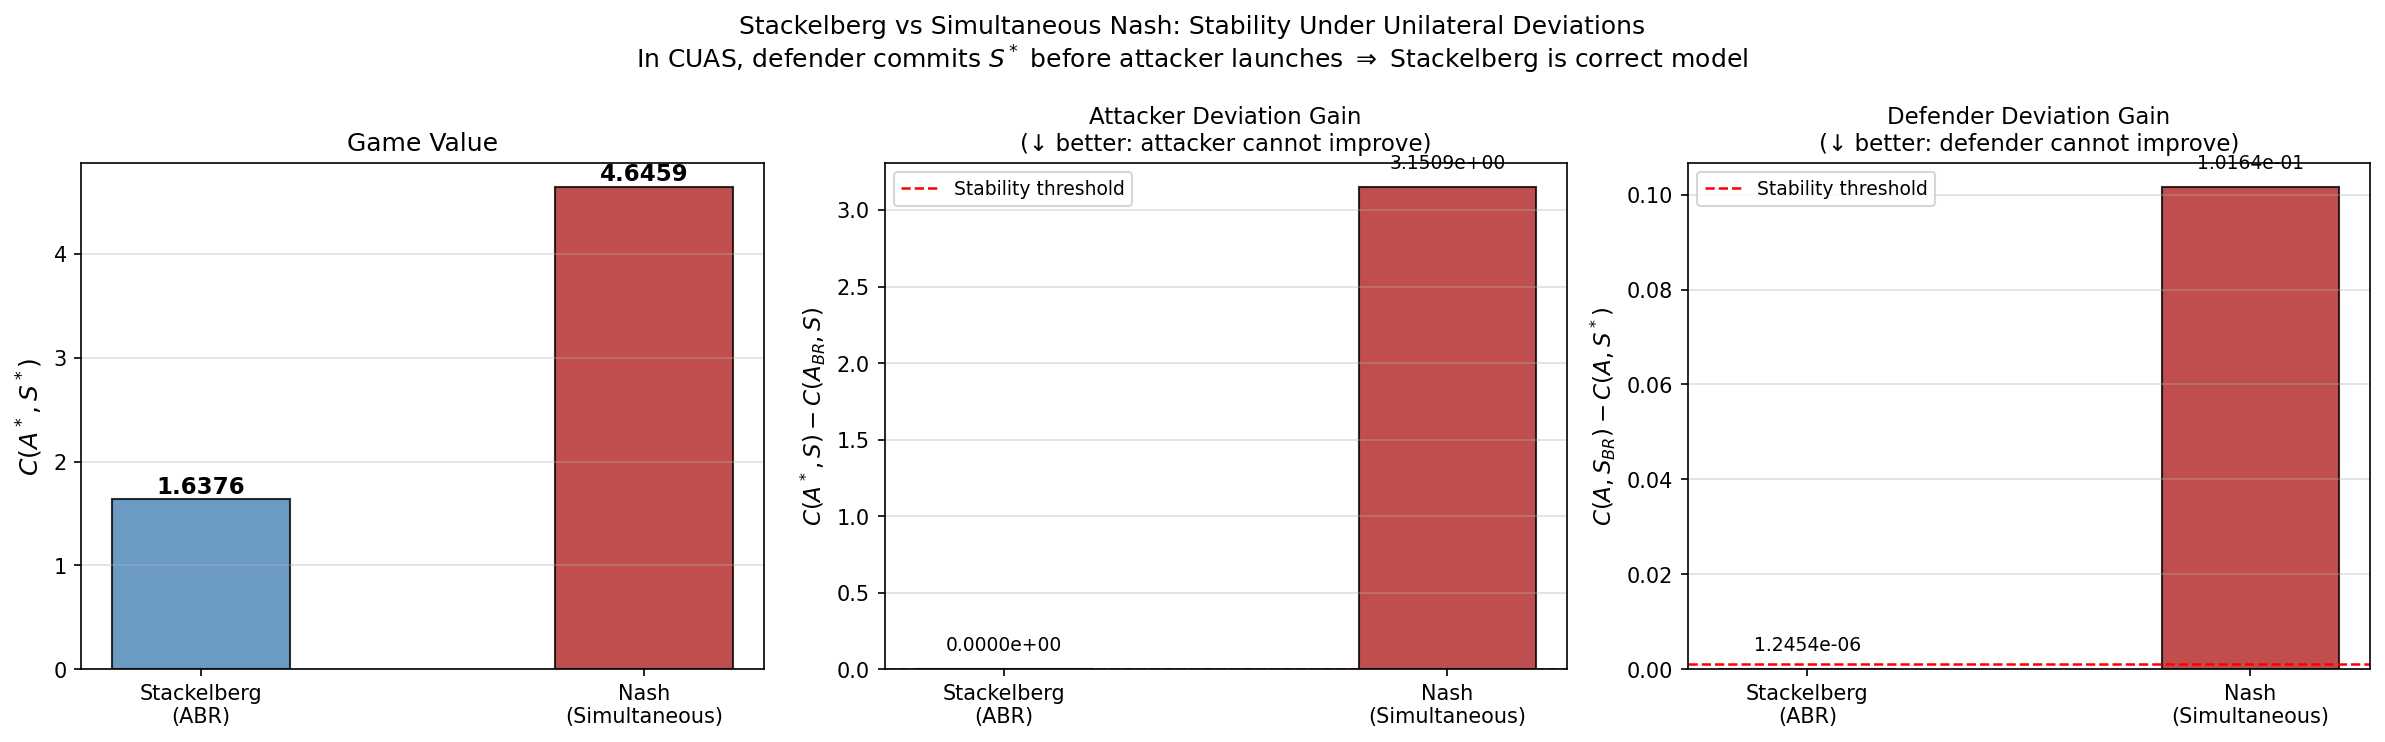

Done.


In [19]:
##############################################################################
# --- Cell 21: Visualization ---
##############################################################################

fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=150)

labels  = ['Stackelberg\n(ABR)', 'Nash\n(Simultaneous)']
c_vals  = [C_stack, C_nash]
pd_vals = [1-np.exp(-C_stack), 1-np.exp(-C_nash)]
colors  = ['steelblue', 'firebrick']

# --- C values ---
ax = axes[0]
bars = ax.bar(labels, c_vals, color=colors, alpha=0.8, edgecolor='black', width=0.4)
for bar, val in zip(bars, c_vals):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.01,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel(r'$C(A^*, S^*)$', fontsize=12)
ax.set_title('Game Value', fontsize=12)
ax.grid(alpha=0.4, axis='y')

# --- Attacker deviation gain ---
ax = axes[1]
gains_att = [att_gain_stack, att_gain_nash]
col_att   = ['steelblue' if g < 1e-3 else 'firebrick' for g in gains_att]
bars2 = ax.bar(labels, gains_att, color=col_att, alpha=0.8, edgecolor='black', width=0.4)
ax.axhline(y=1e-3, color='red', linestyle='--', lw=1.2, label='Stability threshold')
for bar, val in zip(bars2, gains_att):
    ax.text(bar.get_x()+bar.get_width()/2, val+max(gains_att)*0.03,
            f'{val:.4e}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel(r'$C(A^*,S) - C(A_{BR},S)$', fontsize=11)
ax.set_title('Attacker Deviation Gain\n(↓ better: attacker cannot improve)', fontsize=11)
ax.legend(fontsize=9); ax.grid(alpha=0.4, axis='y')

# --- Defender deviation gain ---
ax = axes[2]
gains_def = [def_gain_stack, def_gain_nash]
col_def   = ['steelblue' if g < 1e-3 else 'firebrick' for g in gains_def]
bars3 = ax.bar(labels, gains_def, color=col_def, alpha=0.8, edgecolor='black', width=0.4)
ax.axhline(y=1e-3, color='red', linestyle='--', lw=1.2, label='Stability threshold')
for bar, val in zip(bars3, gains_def):
    ax.text(bar.get_x()+bar.get_width()/2, val+max(gains_def)*0.03,
            f'{val:.4e}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel(r'$C(A,S_{BR}) - C(A,S^*)$', fontsize=11)
ax.set_title('Defender Deviation Gain\n(↓ better: defender cannot improve)', fontsize=11)
ax.legend(fontsize=9); ax.grid(alpha=0.4, axis='y')

plt.suptitle(
    'Stackelberg vs Simultaneous Nash: Stability Under Unilateral Deviations\n'
    r'In CUAS, defender commits $S^*$ before attacker launches $\Rightarrow$ Stackelberg is correct model',
    fontsize=12)
plt.tight_layout()
plt.savefig('image/AD_Game/' + timestamp + '_stackelberg_vs_nash.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Done.')


Computing saddle grid for Stackelberg (ABR)...
  Row 10/101 done
  Row 20/101 done
  Row 30/101 done
  Row 40/101 done
  Row 50/101 done
  Row 60/101 done
  Row 70/101 done
  Row 80/101 done
  Row 90/101 done
  Row 100/101 done
Computing saddle grid for Nash (Simultaneous)...
  Row 10/101 done
  Row 20/101 done
  Row 30/101 done
  Row 40/101 done
  Row 50/101 done
  Row 60/101 done
  Row 70/101 done
  Row 80/101 done
  Row 90/101 done
  Row 100/101 done
Stackelberg axis shift: 0.420
Nash axis shift:        0.000

=== Saddle Check: Stackelberg — ABR (Bilevel) ===
  J at LNE (t=0,s=0) = 0.804931
  Attacker min at t=0.000  (want ~0): ✅
  Defender max at s=0.200  (want ~0): ✅
  ✅ Stackelberg — ABR (Bilevel) IS a local Nash Equilibrium!

=== Saddle Check: Nash — Simultaneous Optimization ===
  J at LNE (t=0,s=0) = 0.990399
  Attacker min at t=-1.000  (want ~0): ❌
  Defender max at s=-0.420  (want ~0): ❌
  ❌ Nash — Simultaneous Optimization not confirmed as local NE.


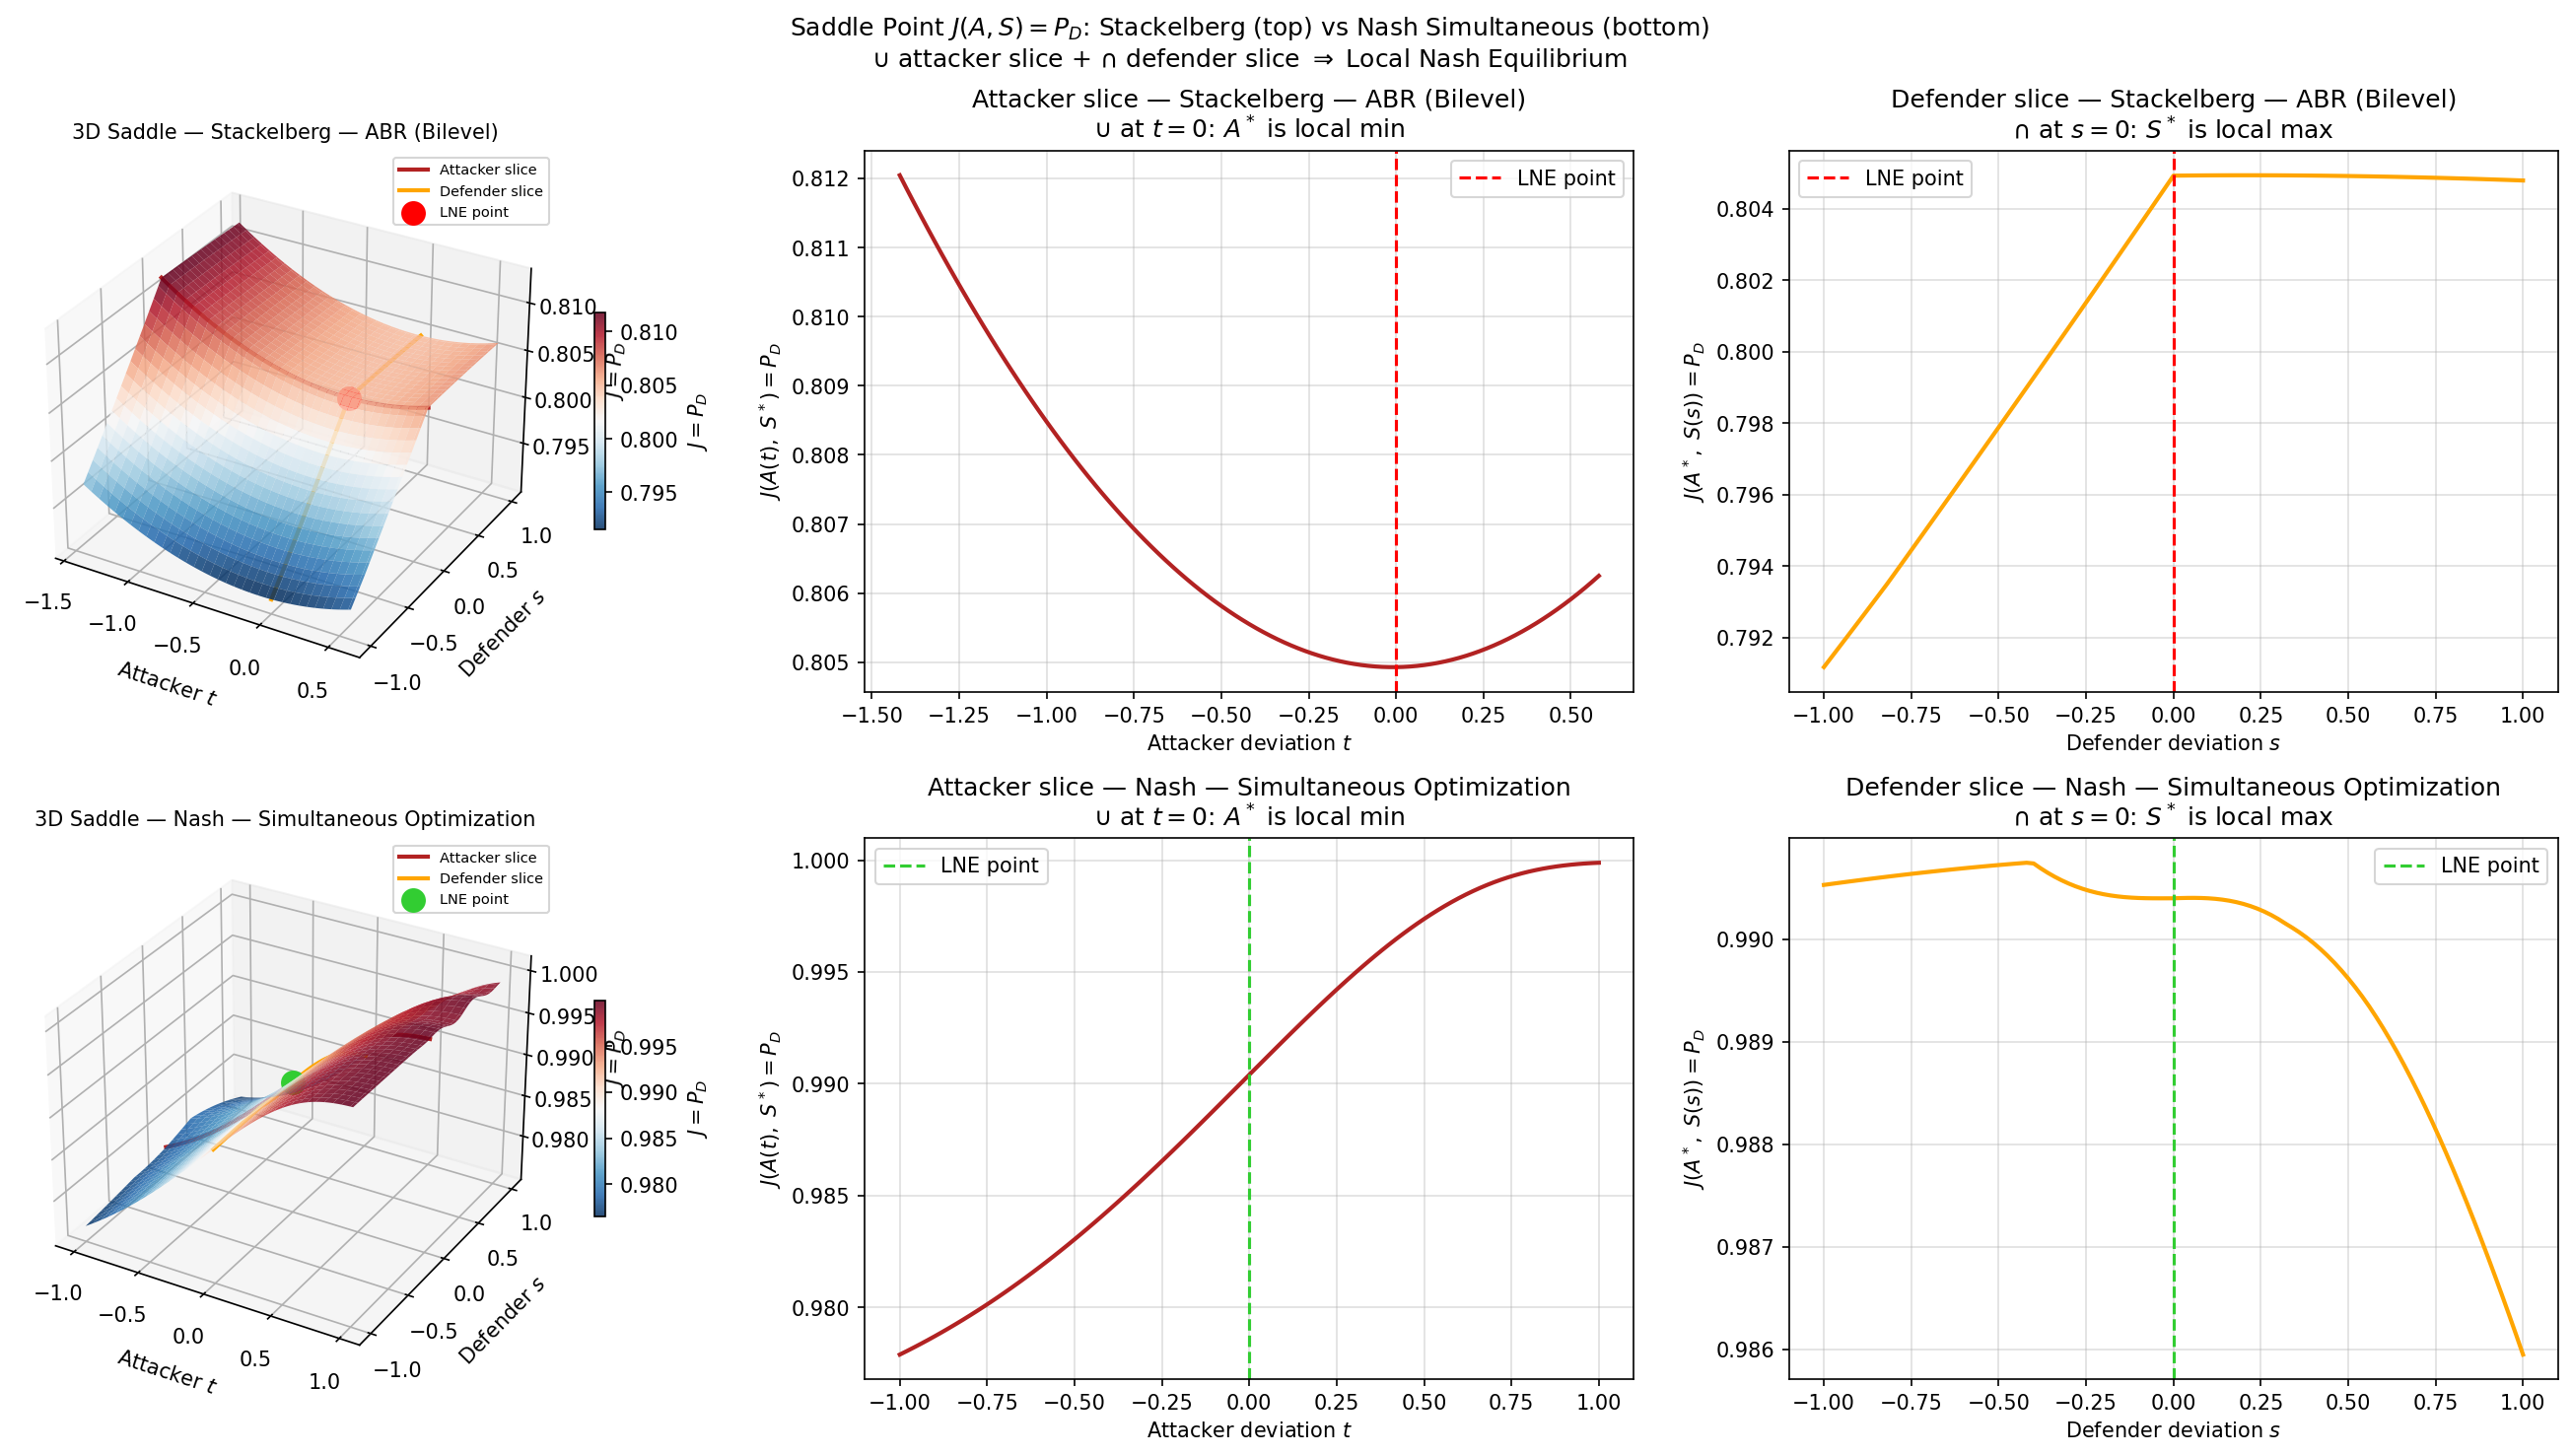

In [24]:
##############################################################################
# --- Cell 22: Saddle Point Contour Comparison ---
# Stackelberg (ABR) vs Simultaneous Nash
# Shows J = P_D = 1 - exp(-C) on axes
# At LNE: attacker slice is U-shaped, defender slice is inverted-U
##############################################################################

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

def alpha_to_S(alpha_np):
    Sx = np.array([building_edge_vec[j][0] +
                   alpha_np[j] * building_vector_vec[j][0]
                   for j in range(cam_dict['n'])])
    Sy = np.array([building_edge_vec[j][1] +
                   alpha_np[j] * building_vector_vec[j][1]
                   for j in range(cam_dict['n'])])
    return np.vstack([Sx, Sy])

def S_to_alpha(S_np):
    alpha = np.zeros(cam_dict['n'])
    for j in range(cam_dict['n']):
        p0 = building_edge_vec[j]
        ve = building_vector_vec[j]
        L2 = float(ve @ ve)
        alpha[j] = float(np.clip((S_np[:,j] - p0) @ ve / L2, 0.0, 1.0)) \
                   if L2 > 1e-12 else 0.0
    return alpha

def perturb_attacker_bump(A_ctr, t, scale=2.0):
    """Sinusoidal bump perpendicular to trajectory — zero at endpoints."""
    x_c = A_ctr[0,:].copy(); y_c = A_ctr[1,:].copy()
    N   = len(x_c) - 1
    bump = np.sin(np.linspace(0, np.pi, N+1))
    dx = np.gradient(x_c); dy = np.gradient(y_c)
    norms = np.sqrt(dx**2 + dy**2) + 1e-9
    perp_x = -dy/norms; perp_y = dx/norms
    x_new = x_c + t * scale * bump * perp_x
    y_new = y_c + t * scale * bump * perp_y
    x_new[0]  = x0[0]; y_new[0]  = x0[1]
    x_new[-1] = xf[0]; y_new[-1] = xf[1]
    return np.vstack([x_new, y_new,
                      np.linspace(A_ctr[2,0], A_ctr[2,-1], N+1)])

def perturb_defender_alpha(alpha_ctr, s, delta_alpha, scale=0.3):
    alpha_new = alpha_ctr + s * scale * delta_alpha
    return np.clip(alpha_new, 0.0, 1.0)

def compute_saddle_grid_J(A_ctr, alpha_ctr, n_grid=51,
                           scale_A=2.0, scale_D=0.3):
    """Compute J = 1-exp(-C) grid for saddle visualization."""
    T_val = float(A_ctr[2,-1] - A_ctr[2,0])

    # Use sign of grad_alpha as perturbation direction
    S_from_alpha = alpha_to_S(alpha_ctr)
    cam_objs_loc = []
    for i in range(cam_dict['n_direc']):
        cam_objs_loc.append(Camera(i, cam_dict,
                                   float(S_from_alpha[0,i]),
                                   float(S_from_alpha[1,i])))

    _x = ca.MX.sym('xl', N_attk+1); _y = ca.MX.sym('yl', N_attk+1)
    _T = ca.MX.sym('Tl'); _al = ca.MX.sym('all', cam_dict['n'])
    _dt = _T / N_attk
    _Sx, _Sy = [], []
    for j in range(cam_dict['n']):
        p0j = building_edge_vec[j]
        sj  = p0j + _al[j]*building_vector_vec[j]
        _Sx.append(sj[0]); _Sy.append(sj[1])
    _S  = ca.vertcat(ca.hcat(_Sx), ca.hcat(_Sy))
    _tn = [path[0][2] + i*_dt for i in range(N_attk+1)]
    _ls = 0
    for i in range(N_attk+1):
        xi=_x[i]; yi=_y[i]; ti=_tn[i]; kp=1.0
        for ci in range(cam_dict['n']):
            dxi=xi-_S[0,ci]; dyi=yi-_S[1,ci]
            dsq=dxi**2+dyi**2; dm=ca.fmax(dsq,1e-4); ds=ca.sqrt(dm)
            if ci < cam_dict['n_direc']:
                co=cam_objs_loc[ci]; phi=co.get_ctr_theta_t(ti); th=co.fov_ang
                ca_=( dxi*ca.cos(phi)+dyi*ca.sin(phi))/ds
                vis=1/(1+ca.exp(-c_param*(ca_-ca.cos(th/2))))
                obs=1/(1+alpha_direc*dm)
            else:
                vis=1.0; obs=1/(1+alpha_omni*dm)
            kp*=(1-vis*obs)
        _ls+=-ca.log(1.0-(1-kp)+1e-9)
    _C = _ls - 0.02*_T
    _gD = ca.gradient(_C, _al)
    fn_gD_loc = ca.Function('gDl',[_x,_y,_T,_al],[_gD])

    gD = np.array(fn_gD_loc(A_ctr[0,:], A_ctr[1,:],
                              T_val, alpha_ctr)).flatten()
    delta_alpha = np.sign(gD); delta_alpha[delta_alpha==0] = 1.0

    t_range = np.linspace(-1.0, 1.0, n_grid)
    s_range = np.linspace(-1.0, 1.0, n_grid)
    J_grid  = np.zeros((n_grid, n_grid))

    for i, t in enumerate(t_range):
        A_t = perturb_attacker_bump(A_ctr, t, scale_A)
        for j_s, s in enumerate(s_range):
            alpha_s = perturb_defender_alpha(alpha_ctr, s, delta_alpha, scale_D)
            S_s = alpha_to_S(alpha_s)
            C_val = eval_C_numeric(A_t, S_s)
            J_grid[i, j_s] = 1.0 - np.exp(-C_val)   # J = P_D
        if (i+1) % 10 == 0:
            print(f'  Row {i+1}/{n_grid} done')

    return t_range, s_range, J_grid


# ------------------------------------------------------------------ #
#  Compute grids for both solutions
# ------------------------------------------------------------------ #
alpha_sim_arr = S_to_alpha(S_sim)   # convert S_sim back to alpha

nGrid = 101

print('Computing saddle grid for Stackelberg (ABR)...')
t_stk, s_stk, Jg_stk = compute_saddle_grid_J(
    A_star, alpha_star, n_grid=nGrid, scale_A=2.0, scale_D=0.3)

print('Computing saddle grid for Nash (Simultaneous)...')
t_nash_g, s_nash_g, Jg_nash = compute_saddle_grid_J(
    A_sim, alpha_sim_arr, n_grid=nGrid, scale_A=2.0, scale_D=0.3)

# ------------------------------------------------------------------ #
#  Shift attacker axis so minimum is at t=0 for each solution
# ------------------------------------------------------------------ #
# def shift_attacker_axis(t_r, J_g):
#     s0 = np.argmin(np.abs(t_r))   # s0 = index of s=0
#     t_min_idx = np.argmin(J_g[:, s0])
#     t_offset  = t_r[t_min_idx]
#     return t_r - t_offset

# t_stk_sh  = shift_attacker_axis(t_stk,   Jg_stk)
# t_nash_sh = shift_attacker_axis(t_nash_g, Jg_nash)

def shift_attacker_axis(t_r, J_g, max_shift=0.5):
    """Shift attacker axis so minimum is at t=0, but cap shift magnitude."""
    s0 = np.argmin(np.abs(t_r))
    t_min_idx = np.argmin(J_g[:, s0])
    t_offset  = t_r[t_min_idx]
    # Only shift if minimum is interior (not at boundary) and shift is small
    if abs(t_offset) > max_shift or t_min_idx == 0 or t_min_idx == len(t_r)-1:
        return t_r, 0.0   # no shift — minimum is at boundary
    return t_r - t_offset, t_offset

t_stk_sh,  offset_stk  = shift_attacker_axis(t_stk,   Jg_stk)
t_nash_sh, offset_nash = shift_attacker_axis(t_nash_g, Jg_nash)

print(f'Stackelberg axis shift: {offset_stk:.3f}')
print(f'Nash axis shift:        {offset_nash:.3f}')

# ------------------------------------------------------------------ #
#  Plot: 2 rows x 3 cols (Stackelberg top, Nash bottom)
# ------------------------------------------------------------------ #
fig = plt.figure(figsize=(18, 10), dpi=150)

for row, (t_r, s_r, J_g, label, color_pt) in enumerate([
    (t_stk_sh,  s_stk,   Jg_stk,  'Stackelberg — ABR (Bilevel)',      'red'),
    (t_nash_sh, s_nash_g, Jg_nash, 'Nash — Simultaneous Optimization', 'limegreen'),
]):
    t0 = np.argmin(np.abs(t_r))
    s0 = np.argmin(np.abs(s_r))
    T_mesh, S_mesh = np.meshgrid(t_r, s_r, indexing='ij')
    n_g = len(t_r)

    # 3D surface
    ax3d = fig.add_subplot(2, 3, row*3+1, projection='3d')
    surf = ax3d.plot_surface(T_mesh, S_mesh, J_g,
        cmap=cm.RdBu_r, alpha=0.85, linewidth=0, antialiased=True)
    ax3d.plot(t_r, np.zeros(n_g), J_g[:,s0],
              '-', color='firebrick', lw=2.0, label='Attacker slice')
    ax3d.plot(np.zeros(n_g), s_r, J_g[t0,:],
              '-', color='orange', lw=2.0, label='Defender slice')
    ax3d.scatter([0],[0],[J_g[t0,s0]], color=color_pt,
                 s=120, zorder=10, label='LNE point')
    fig.colorbar(surf, ax=ax3d, shrink=0.4, label=r'$J = P_D$')
    ax3d.set_xlabel(r'Attacker $t$', labelpad=6)
    ax3d.set_ylabel(r'Defender $s$', labelpad=6)
    ax3d.set_zlabel(r'$J = P_D$', labelpad=6)
    ax3d.set_title(f'3D Saddle — {label}', fontsize=10)
    ax3d.legend(fontsize=7)

    # Attacker slice
    ax_att = fig.add_subplot(2, 3, row*3+2)
    ax_att.plot(t_r, J_g[:,s0], '-', color='firebrick', lw=2.0)
    ax_att.axvline(x=0, color=color_pt, linestyle='--',
                   lw=1.5, label='LNE point')
    ax_att.set_xlabel(r'Attacker deviation $t$')
    ax_att.set_ylabel(r'$J(A(t),\ S^*) = P_D$')
    ax_att.set_title(f'Attacker slice — {label}\n'
                     r'$\cup$ at $t=0$: $A^*$ is local min')
    ax_att.legend(); ax_att.grid(alpha=0.4)

    # Defender slice
    ax_def = fig.add_subplot(2, 3, row*3+3)
    ax_def.plot(s_r, J_g[t0,:], '-', color='orange', lw=2.0)
    ax_def.axvline(x=0, color=color_pt, linestyle='--',
                   lw=1.5, label='LNE point')
    ax_def.set_xlabel(r'Defender deviation $s$')
    ax_def.set_ylabel(r'$J(A^*,\ S(s)) = P_D$')
    ax_def.set_title(f'Defender slice — {label}\n'
                     r'$\cap$ at $s=0$: $S^*$ is local max')
    ax_def.legend(); ax_def.grid(alpha=0.4)

    # Saddle check
    t_min_idx = np.argmin(J_g[:,s0])
    s_max_idx = np.argmax(J_g[t0,:])
    att_ok = abs(t_r[t_min_idx]) < 0.15
    def_ok = abs(s_r[s_max_idx]) < 0.2
    print(f'\n=== Saddle Check: {label} ===')
    print(f'  J at LNE (t=0,s=0) = {J_g[t0,s0]:.6f}')
    print(f'  Attacker min at t={t_r[t_min_idx]:.3f}  (want ~0): {"✅" if att_ok else "❌"}')
    print(f'  Defender max at s={s_r[s_max_idx]:.3f}  (want ~0): {"✅" if def_ok else "❌"}')
    if att_ok and def_ok:
        print(f'  ✅ {label} IS a local Nash Equilibrium!')
    else:
        print(f'  ❌ {label} not confirmed as local NE.')

plt.suptitle(
    r'Saddle Point $J(A,S) = P_D$: Stackelberg (top) vs Nash Simultaneous (bottom)' + '\n' +
    r'$\cup$ attacker slice + $\cap$ defender slice $\Rightarrow$ Local Nash Equilibrium',
    fontsize=12)
plt.tight_layout()
plt.savefig('image/AD_Game/' + timestamp + '_saddle_comparison_J.png',
            dpi=150, bbox_inches='tight')
plt.show()